<a href="https://colab.research.google.com/github/data-shkim/book-self-study-ml-dl/blob/main/%ED%98%BC%EC%9E%90%EA%B3%B5%EB%B6%80%ED%95%98%EB%8A%94%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%2B%EB%94%A5%EB%9F%AC%EB%8B%9D_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')

wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [ ]:
wine.info() # 6,497개의 데이터가 있고, non-null count가 6,497개 있으므로 누락된 값이 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [ ]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [ ]:
data = wine[['alcohol', 'sugar', 'pH']]
target = wine[['class']]

,class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
6492,1.0
6493,1.0
6494,1.0
6495,1.0


In [ ]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(data, target, test_size = 0.2, random_state=42)
print(train_input.shape, test_input.shape)
print(6497*0.2) # 전체의 20% 를 테스트 데이터로

(5197, 3) (1300, 3)
1299.4


In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

print(test_scaled)
print(sum(test_scaled))
print(len(test_scaled[0]))

[[ 1.44082714  1.52797084  0.26967864]
 [-0.48990299 -0.68214836  0.3323304 ]
 [ 1.27293756  0.40206106 -0.23153545]
 ...
 [ 1.60871671 -0.76554908 -0.16888369]
 [-0.90962693  0.88161523  0.52028568]
 [-1.49724045  2.09092573 -1.98578474]]
[ 44.71861889 -38.51367265  62.88534543]
3


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

lr = LogisticRegression()
lr.fit(train_scaled, np.array(train_target).ravel())
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

# print(np.array(test_target))
# print(np.array(test_target).ravel())

# DataCoversionWarning : 1차원 배열을 기대하는데 2차원 배열을 넘겨서 발생 -> ravel() 로 1차원 배열로 변경
# /usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


0.7808350971714451
0.7776923076923077


In [ ]:
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [ ]:
# 결정트리(Decision Tree): 위와 같이 계수와 절편으로 설명하는 것이 아닌 데이터를 나누는 조건으로 트리 구조로 데이터를 나누어감
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))
# train score 가 많이 높고 test score 가 낮음 => 과대적합

0.996921300750433
0.8592307692307692


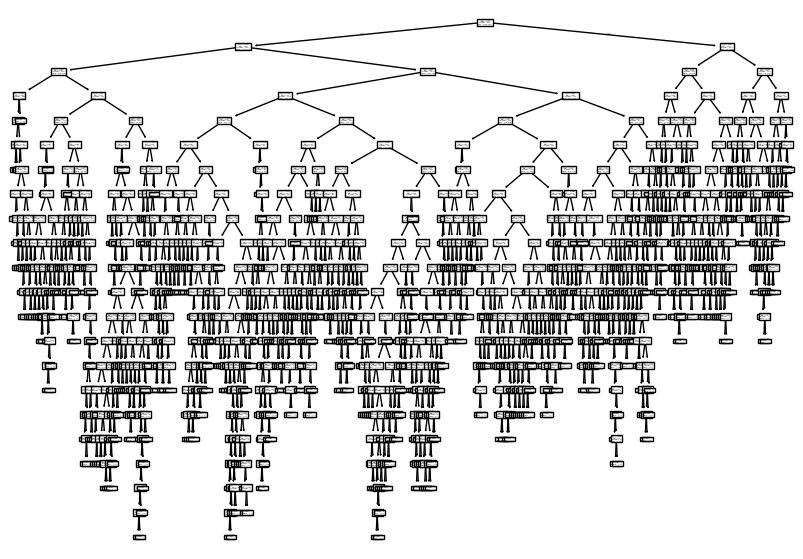

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

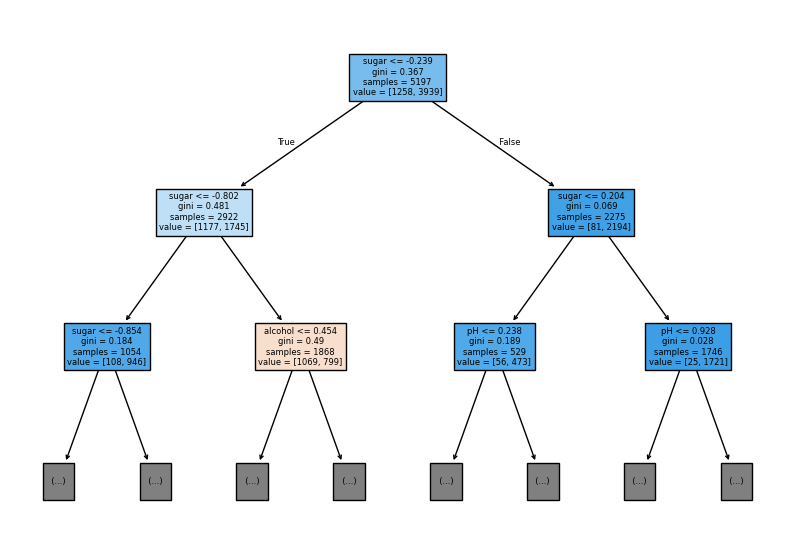

In [ ]:
plt.figure(figsize=(10, 7))
plot_tree(dt, max_depth=2, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
# gini(Gini impurity): 지니 불순도
# = 1 - (음성클래스비율^2 + 양성클래스비율^2)
# 한쪽으로 치우치면 0에 가까워지고 판단할 수 없는 경우는 0.5 (반반)
# 부모의 불순도 - {(왼쪽노드샘플수 / 부모샘플수) * (왼쪽노드불순도) + (오른쪽노드샘플수 / 부모샘플수) * (오른쪽노드불순도)} = 정보이득(information gain)


In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


0.8454877814123533
0.8415384615384616
[0.12345626 0.86862934 0.0079144 ]


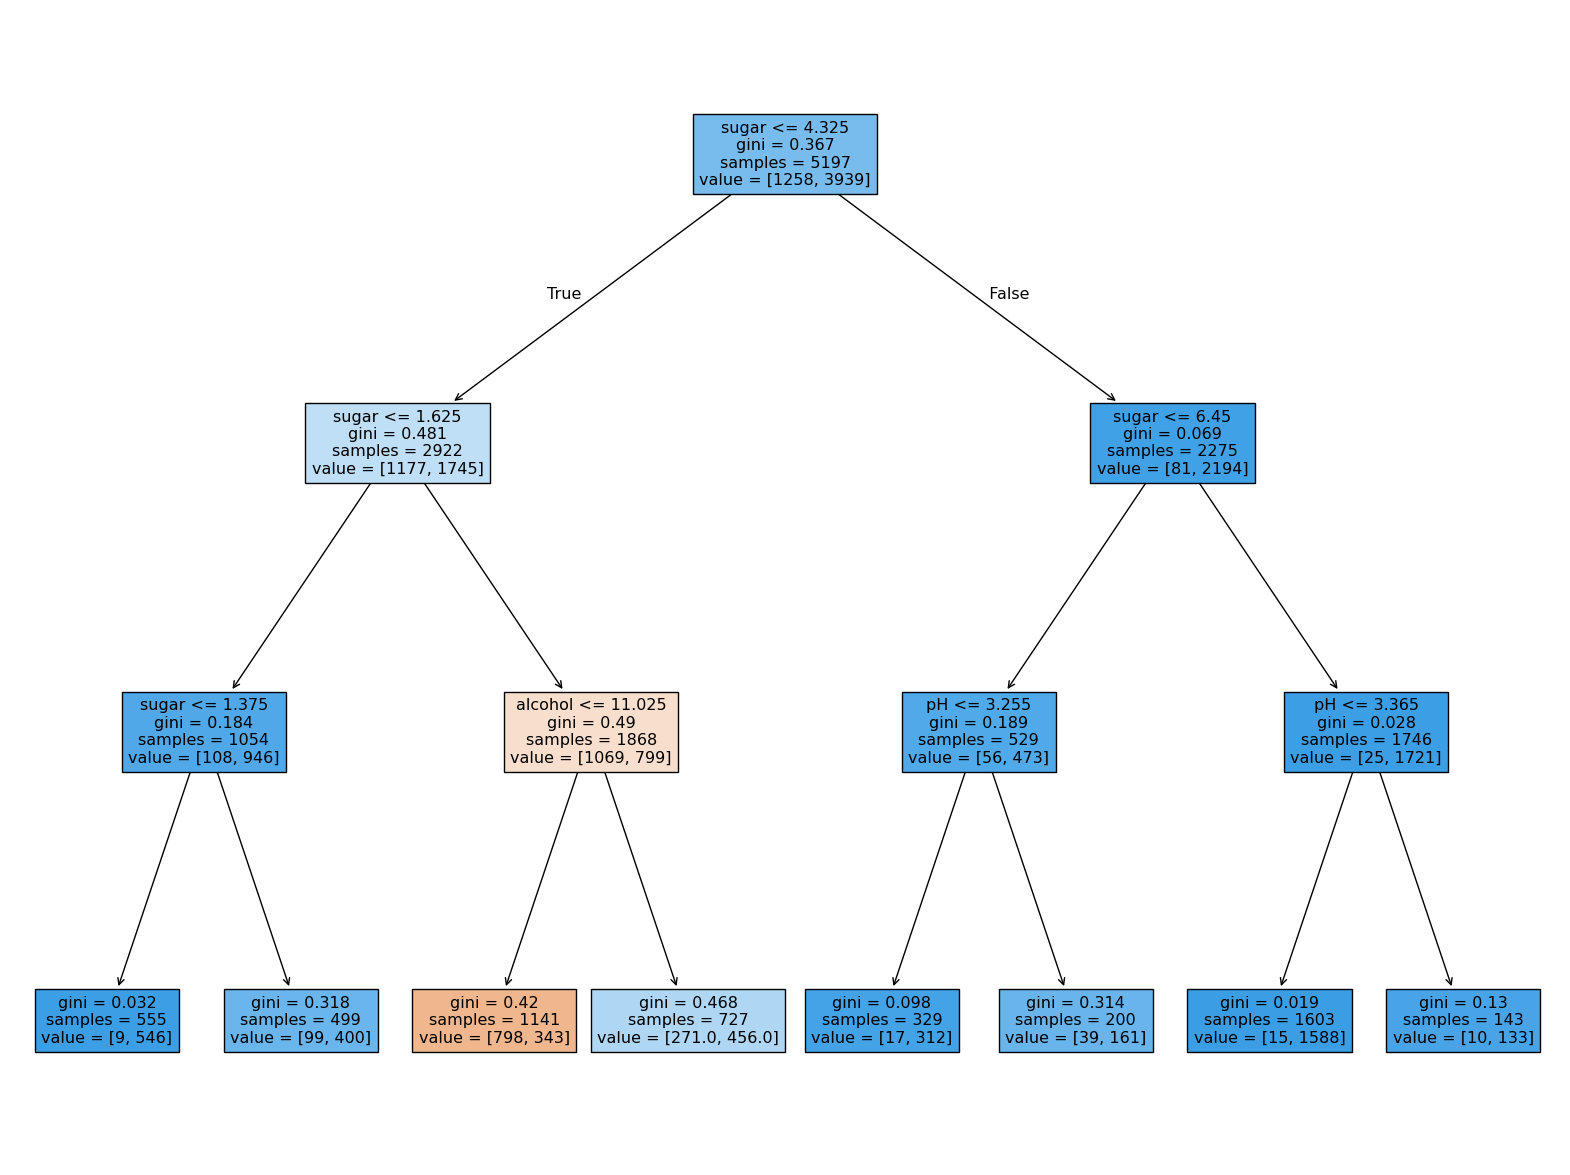

In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))
print(dt.feature_importances_)  # 특성 중요도

plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

# 표준화를 하지 않아도 같은 결과 반환, 표준화하지 않아서 트리를 이해하기 더 쉬움

In [ ]:
dt = DecisionTreeClassifier(min_impurity_decrease=0.0005, random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))
# plt.figure(figsize=(20,15))
# plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
# plt.show()

# min_impurity_decrease=0.0005 성능은 max_depth=3 으로 했을 때 보다 좋음

0.8874350586877044
0.8615384615384616
